In [1]:
import sys, platform, os
import numpy as np
import matplotlib.pyplot as plt
import scipy

import camb
from camb import model, initialpower

import healpy as hp

import torch
import torch.nn as nn
from torch.nn import Sequential, Linear, ReLU, ModuleList, LayerNorm
import torch.nn.functional as F

from healpy.projector import GnomonicProj
from scipy.stats import binned_statistic_2d
from scipy.interpolate import griddata
from scipy.interpolate import interpn

from scipy.ndimage import gaussian_filter

In [2]:
soft_path = "/home/belen/Doctorado/ML/curvesky/polarizacion/soft/source/" #put software path
sys.path.append(os.path.abspath(soft_path))

In [3]:
import projections as pj
import utilities
import make_dataset as dd

In [4]:
sky_region = pj.sph_mask(nside=512, radius=40, move=True)
mask40, valid_index, vecs, vec_center, theta_idx, phi_idx, lonc, latc = sky_region.make_mask()
maskSO, nhitsSO, valid_index_SO, vecs_SO, vec_center_SO, theta_idx_SO, phi_idx_SO, lonc_SO, latc_SO = sky_region.make_SO_mask()


In [5]:
cltt, clee, clbb = utilities.signal_spectrum()

In [6]:
nside = 512
lmax = len(cltt)
cls = np.zeros((6, lmax))  # (cltt, clte, clee, clbb
cls[0] = cltt  # TT  
cls[2] = clee  # EE
cls[3] = clbb  # BB

ele = np.arange(len(cltt))

fwhm = np.radians(23/60)
beam = utilities.bl(fwhm, len(ele)-1)

nltt = np.zeros((len(cltt)))
nltt[:] = 1e-2

In [7]:
make_data = dd.make_dataset(nsims_train=1, nsims_valid=1, nsims_test=1, smooth=True, apo=False,
                            nbins=512, nside=512, fwhm=23,
                            DEFAULT_NOISE_LEVEL=1e-2)

In [8]:
# spherical map 
mapT,_,_ = make_data.get_QUmaps(beam=False)
map_noise,_ = make_data.get_QUnoise(nltt)

In [9]:
mapT_smooth = hp.smoothing(mapT, fwhm = np.radians(23/60))
map_data = mapT_smooth + map_noise # (Bs_sph + n_sph)
masked_data = mask40*map_data
maskedSO_data = maskSO*map_data

In [10]:
wl_sph = beam*cltt/(cltt*beam**2 + nltt)

In [11]:
lmax = 3*nside-1
alm_d = hp.map2alm(map_data, lmax)
alm_f = hp.almxfl(alm_d, wl_sph)
wf_sph =  hp.alm2map(alm_f, nside)

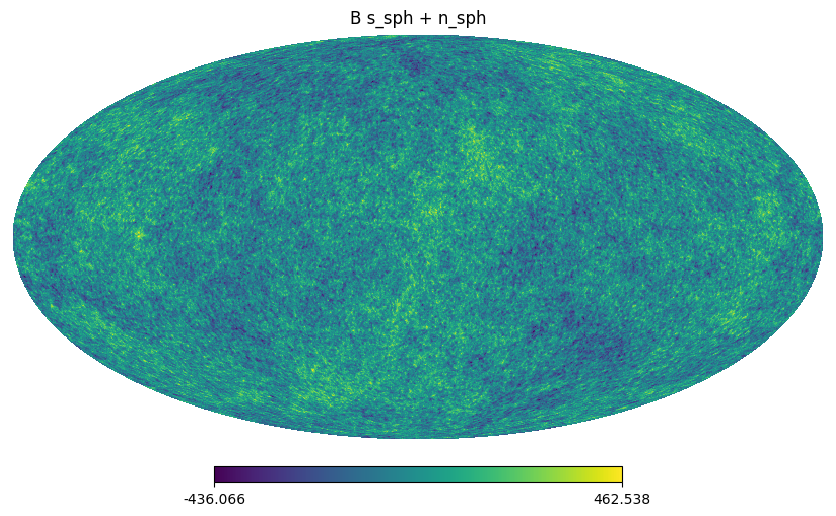

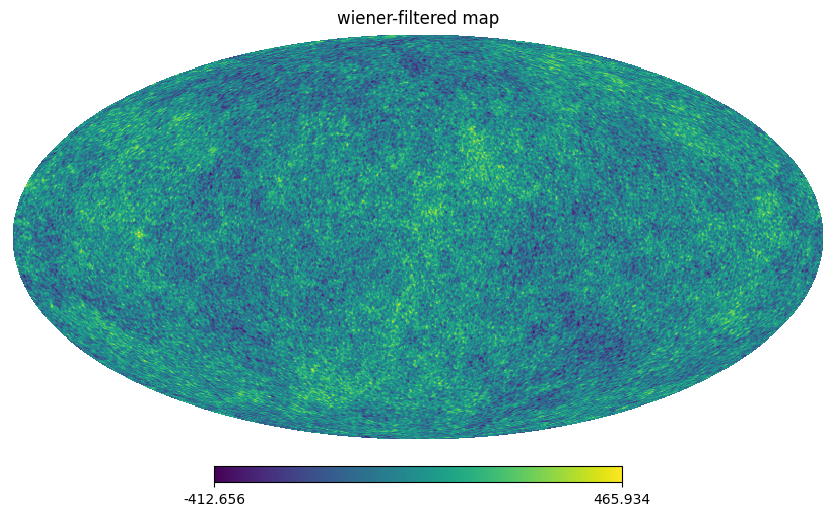

In [12]:
hp.mollview(map_data, title="B s_sph + n_sph")
hp.mollview(wf_sph, title="wiener-filtered map")

In [12]:
cltt_wf = hp.anafast(wf_sph)
cltt_sb = hp.anafast(map_data)
ele2 = np.arange(len(cltt_wf))

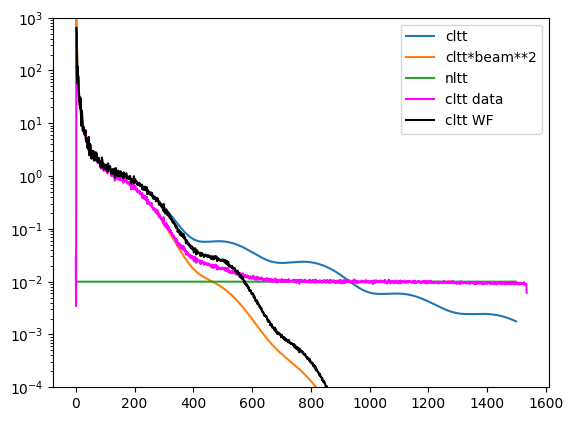

In [13]:
plt.plot(ele[2:1500], cltt[2:1500], label='cltt')
plt.plot(ele[2:1500], cltt[2:1500]*beam[2:1500]**2, label='cltt*beam**2')

plt.plot(ele[2:1500], nltt[2:1500], label='nltt')
plt.plot(ele2, cltt_sb, color='magenta', label='cltt data')
plt.plot(ele2[2:], cltt_wf[2:], color='black', label='cltt WF')
plt.ylim(1e-4, 1e3)
plt.yscale('log')
plt.legend()

In [52]:
# planer map

In [13]:
theta0, phi0 = hp.vec2ang(vec_center)
theta, phi = hp.vec2ang(vecs)
proj = pj.proj_2d(lonc, latc, theta_idx, phi_idx, vec_center, nbins=512, fact=8)
z_eq, z_tan, z_str = proj.proj_conventions(vecs, vec_center)

#theta0_SO, phi0_SO = hp.vec2ang(vec_center_SO)
#theta_SO, phi_SO = hp.vec2ang(vecs_SO)
#proj_SO = pj.proj_2d(lonc_SO, latc_SO, theta_idx_SO, phi_idx_SO, vec_center_SO, nbins=704, fact=8)
#z_eq_SO, z_tan_SO, z_str_SO = proj.proj_conventions(vecs_SO, vec_center_SO)

In [51]:
#mask2d = proj.define_region_mask_nbins_margins(z_eq, mask40, nside = 512)
#mask2d_rect, nbins_x, nbins_y = proj_SO.define_region_mask_from_res_margins(z_eq_SO, maskSO, nside=512) # shape (ny, nx)


In [14]:
data_piece = map_data[valid_index]
grid_str, grid_x_str, grid_y_str, inside_str, z_str_inside = proj.grid_cuad(z_str, data_piece)
grid_eq, grid_x_eq, grid_y_eq, inside_eq, z_eq_inside = proj.grid_cuad(z_eq, data_piece)
grid_gnom, grid_x_gnom, grid_y_gnom, inside_gnom, z_gnom_inside = proj.grid_cuad(z_tan, data_piece)

In [15]:
grid_str = grid_str - np.mean(grid_str)
grid_eq = grid_eq - np.mean(grid_eq)
grid_gnom = grid_gnom - np.mean(grid_gnom)


Text(0.5, 1.0, 'stereographic')

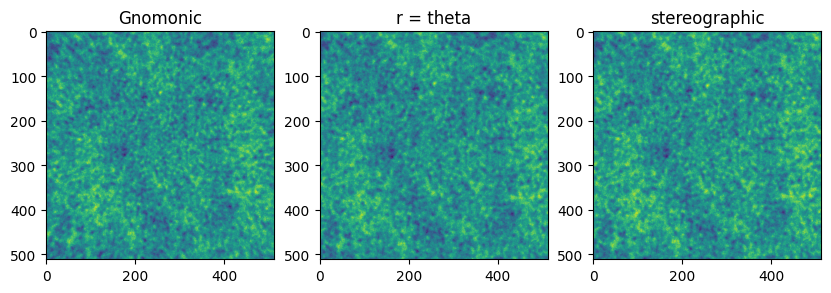

In [17]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

ax[0].imshow(grid_gnom)
ax[0].set_title('Gnomonic')
ax[1].imshow(grid_eq)
ax[1].set_title('r = theta')
ax[2].imshow(grid_str)
ax[2].set_title('stereographic')


In [17]:
valid_index_inside_eq = valid_index[inside_eq]
valid_index_inside_str = valid_index[inside_str]
valid_index_inside_gnom = valid_index[inside_gnom]

WF_map_mask = mask40*wf_sph
WF_piece_inside_gnom = WF_map_mask[valid_index_inside_gnom]
WF_piece_inside_eq = WF_map_mask[valid_index_inside_eq]
WF_piece_inside_str = WF_map_mask[valid_index_inside_str]

npix = hp.nside2npix(512)
mask_inside_eq = np.zeros(npix)
mask_inside_eq[valid_index_inside_eq] = 1
mask_inside_str = np.zeros(npix)
mask_inside_str[valid_index_inside_str] = 1
mask_inside_gnom = np.zeros(npix)
mask_inside_gnom[valid_index_inside_gnom] = 1


In [20]:
pixels_in_disc = np.where(mask40==1)[0]
area = np.degrees(np.sqrt(len(pixels_in_disc)*hp.nside2pixarea(nside=512))) # nro pixels * área pixel

area_patch =  np.degrees(np.sqrt(len(valid_index_inside_eq)*hp.nside2pixarea(nside=512)))

In [22]:
print('area', area)
print('area patch', area_patch)

area 69.46604873680963
area patch 55.8060668406661


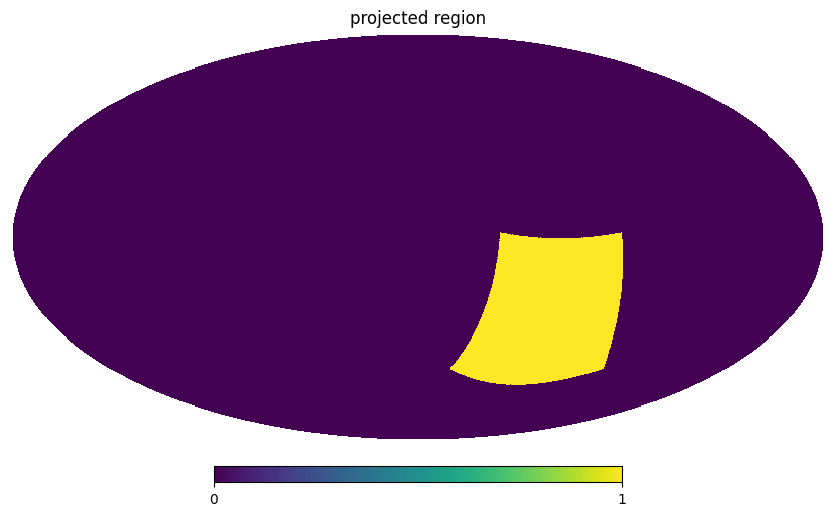

In [71]:
hp.mollview(mask_inside_eq, title='projected region')

In [77]:
dx_gnom

(np.float64(0.002317661264958429),
 np.float64(0.0023176841588623707),
 np.float64(0.0023176727119103998))

In [19]:
_,_,dx_gnom = utilities.calculate_res(z_gnom_inside, 512, 512)
_,_,dx_eq = utilities.calculate_res(z_eq_inside, 512, 512)
_,_,dx_str = utilities.calculate_res(z_str_inside, 512, 512)

ell_flat_gnom, cl_flat_gnom = utilities.power_spectrum_flat(cltt, nx = 512, ny = 512, dx = dx_gnom, dy = dx_gnom)
ell_flat_eq, cl_flat_eq = utilities.power_spectrum_flat(cltt, nx = 512, ny = 512, dx = dx_eq, dy = dx_eq)
ell_flat_str, cl_flat_str = utilities.power_spectrum_flat(cltt, nx = 512, ny = 512, dx = dx_str, dy = dx_str)

_, nl_flat_gnom = utilities.power_spectrum_flat(nltt, nx = 512, ny = 512, dx = dx_gnom, dy = dx_gnom)
_, nl_flat_eq = utilities.power_spectrum_flat(nltt, nx = 512, ny = 512, dx = dx_eq, dy = dx_eq)
_, nl_flat_str = utilities.power_spectrum_flat(nltt, nx = 512, ny = 512, dx = dx_str, dy = dx_str)


beam_gnom = utilities.beam_flat(fwhm, ell_flat_gnom)
beam_str = utilities.beam_flat(fwhm, ell_flat_str)
beam_eq = utilities.beam_flat(fwhm, ell_flat_eq)

In [20]:
wl_pln_gnom = beam_gnom*cl_flat_gnom/(cl_flat_gnom*beam_gnom**2 + nl_flat_gnom)
wl_pln_eq = beam_eq*cl_flat_eq/(cl_flat_eq*beam_eq**2 + nl_flat_eq)
wl_pln_str = beam_str*cl_flat_str/(cl_flat_str*beam_str**2 + nl_flat_str)

def wf_power(map, W, dx, nx):

    #tfac = np.sqrt((dx*dx)/(nx*nx))
    fft = np.fft.rfft2(map)#*tfac
    fft_wf = W*fft
    wf_map = np.fft.irfft2(fft_wf)#/tfac
    
    return fft, fft_wf, wf_map

In [21]:
_,_,wf_pln_gnom = wf_power(grid_gnom, wl_pln_gnom.reshape(512,257), dx_gnom, nx = 512)
_,_,wf_pln_eq = wf_power(grid_eq, wl_pln_eq.reshape(512,257), dx_eq, nx = 512)
_,_,wf_pln_str = wf_power(grid_str, wl_pln_str.reshape(512,257), dx_str, nx = 512)


Text(0.5, 1.0, 'stereographic')

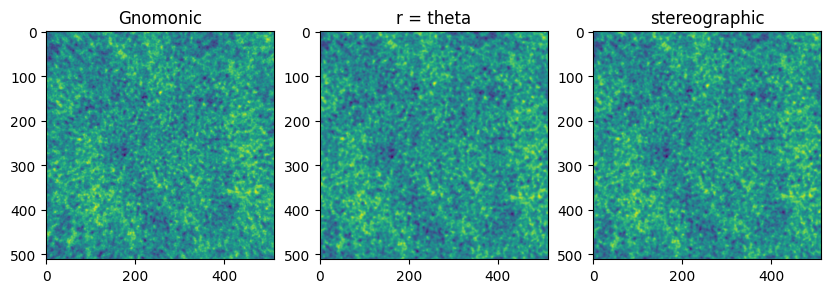

In [22]:
fig, ax = plt.subplots(1,3, figsize=(10,5))

ax[0].imshow(wf_pln_gnom)
ax[0].set_title('Gnomonic')
ax[1].imshow(wf_pln_eq)
ax[1].set_title('r = theta')
ax[2].imshow(wf_pln_str)
ax[2].set_title('stereographic')

In [23]:
mapped_str = proj.deprojection(z_str_inside, wf_pln_str, grid_x_str, grid_y_str)
mapped_eq = proj.deprojection(z_eq_inside, wf_pln_eq, grid_x_eq, grid_y_eq)
mapped_gnom = proj.deprojection(z_gnom_inside, wf_pln_gnom, grid_x_gnom, grid_y_gnom)

In [70]:
WF_piece_inside_str = WF_piece_inside_str - np.mean(WF_piece_inside_str)
WF_piece_inside_eq = WF_piece_inside_eq - np.mean(WF_piece_inside_eq)
WF_piece_inside_gnom = WF_piece_inside_gnom - np.mean(WF_piece_inside_gnom)


In [29]:
projwf_str = np.zeros(npix)
projwf_str[valid_index_inside_str] = mapped_str

sphwf_str = np.zeros(npix)
sphwf_str[valid_index_inside_str] = WF_piece_inside_str - np.mean(WF_piece_inside_str)

projwf_eq = np.zeros(npix)
projwf_eq[valid_index_inside_eq] = mapped_eq

sphwf_eq = np.zeros(npix)
sphwf_eq[valid_index_inside_eq] = WF_piece_inside_eq - np.mean(WF_piece_inside_eq)

projwf_gnom = np.zeros(npix)
projwf_gnom[valid_index_inside_gnom] = mapped_gnom

sphwf_gnom = np.zeros(npix)
sphwf_gnom[valid_index_inside_gnom] = WF_piece_inside_gnom - np.mean(WF_piece_inside_gnom)

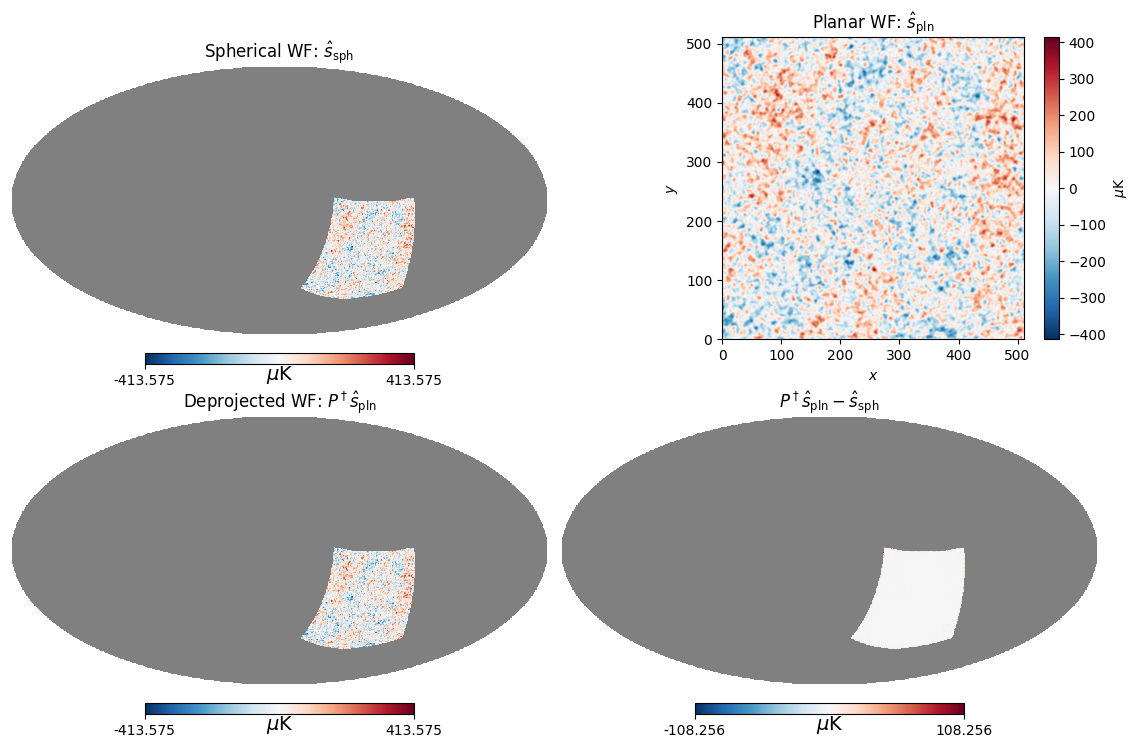

In [83]:
# WF computed directly on the sphere,
# restricted to the region covered by the projection
sphwf_eq_plot = np.full(npix, hp.UNSEEN)
sphwf_eq_plot[valid_index_inside_eq] = WF_piece_inside_eq

# WF computed in the plane and deprojected back onto the sphere
projwf_eq_plot = np.full(npix, hp.UNSEEN)
projwf_eq_plot[valid_index_inside_eq] = mapped_eq


# Residual:
# planar WF -> sphere  minus  spherical WF
residual_eq_plot = np.full(npix, hp.UNSEEN)

residual_eq = mapped_eq - WF_piece_inside_eq

residual_eq_plot[valid_index_inside_eq] = residual_eq

# Same scale for spherical, planar and deprojected WF maps
vmax = max(
    np.max(np.abs(WF_piece_inside_eq)),
    np.max(np.abs(wf_pln_eq)),
    np.max(np.abs(mapped_eq))
)

# Independent scale for residual
vmax_res = np.max(np.abs(residual_eq))


fig = plt.figure(figsize=(11, 7))


# ------------------------------------------------------------
# 1. WF computed directly on the sphere
# ------------------------------------------------------------

hp.mollview(sphwf_eq_plot, fig=fig.number, sub=(2, 2, 1), title=r"Spherical WF: $\hat{s}_{\rm sph}$",
    min=-vmax,
    max=vmax,
    cmap="RdBu_r",
    cbar=True,
    unit=r"$\mu$K"
)


# ------------------------------------------------------------
# 2. WF computed in the projected plane
# ------------------------------------------------------------

ax = fig.add_subplot(2, 2, 2)

im = ax.imshow(
    wf_pln_eq,
    origin="lower",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
    aspect="equal"
)

ax.set_title(r"Planar WF: $\hat{s}_{\rm pln}$")
ax.set_xlabel("$x$")
ax.set_ylabel("$y$")

cbar = fig.colorbar(
    im,
    ax=ax,
    fraction=0.046,
    pad=0.04
)

cbar.set_label(r"$\mu$K")


# ------------------------------------------------------------
# 3. Planar WF deprojected back onto the sphere
# ------------------------------------------------------------

hp.mollview(
    projwf_eq_plot,
    fig=fig.number,
    sub=(2, 2, 3),
    title=r"Deprojected WF: $P^\dagger\hat{s}_{\rm pln}$",
    min=-vmax,
    max=vmax,
    cmap="RdBu_r",
    cbar=True,
    unit=r"$\mu$K"
)


# ------------------------------------------------------------
# 4. Residual
# ------------------------------------------------------------

hp.mollview(
    residual_eq_plot,
    fig=fig.number,
    sub=(2, 2, 4),
    title=r"$P^\dagger\hat{s}_{\rm pln}-\hat{s}_{\rm sph}$",
    min=-vmax_res,
    max=vmax_res,
    cmap="RdBu_r",
    cbar=True,
    unit=r"$\mu$K"
)


# ============================================================
# Final layout
# ============================================================

plt.subplots_adjust(
    left=0.01,
    right=0.97,
    bottom=0.05,
    top=1,
    wspace=0.18,
    hspace=0.2
)
plt.savefig('mollview_plots.pdf', bbox_inches='tight', pad_inches=0)
plt.show()



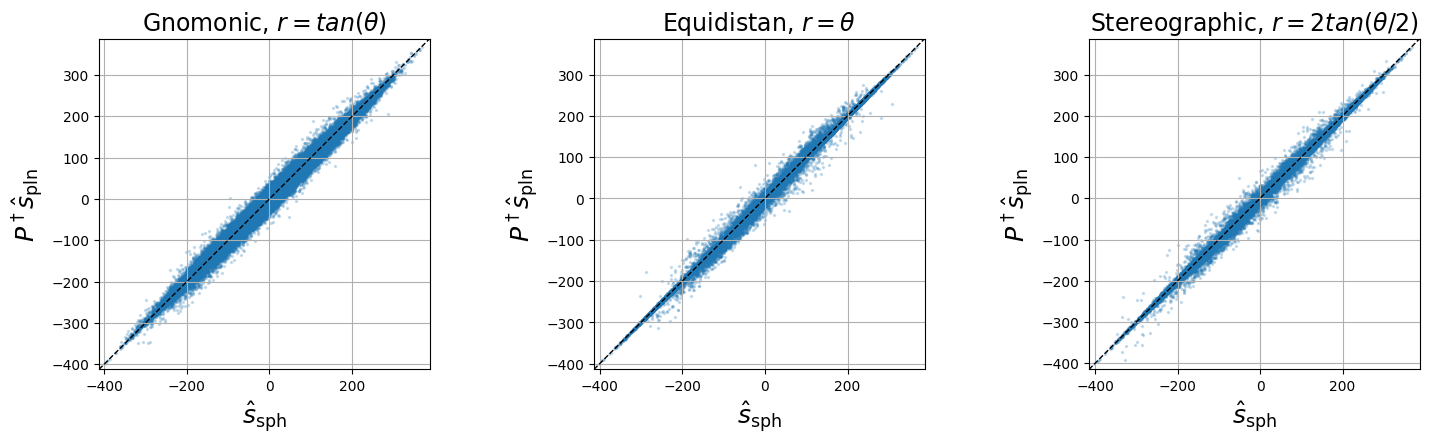

In [112]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.5))

data = [
    (r"Gnomonic, $r = tan(\theta)$", WF_piece_inside_gnom, mapped_gnom),
    (r"Equidistan, $r=\theta$", WF_piece_inside_eq, mapped_eq),
    (r"Stereographic, $r = 2 tan(\theta/2)$", WF_piece_inside_str, mapped_str),
]

for a, (title, sph, pln) in zip(ax, data):

    a.scatter(
        sph,
        pln,
        s=2,
        alpha=0.2
    )

    vmin = min(sph.min(), pln.min())
    vmax = max(sph.max(), pln.max())

    a.plot(
        [vmin, vmax],
        [vmin, vmax],
        "k--",
        lw=1
    )

    a.set_xlim(vmin, vmax)
    a.set_ylim(vmin, vmax)

    a.set_xlabel(r"$\hat{s}_{\rm sph}$", fontsize=18)
    a.set_ylabel(r"$P^\dagger\hat{s}_{\rm pln}$", fontsize=18)

    a.set_title(title, fontsize=17)
    a.grid()

    a.set_aspect("equal", adjustable="box")

plt.tight_layout()
plt.savefig('scatter.png', bbox_inches='tight')

plt.show()

In [47]:
import pymaster as nmt

In [44]:
def use_namaster(mask, map1, map2, bin_edges, apodize = True, apod_scale=0.5):

    if apodize == True: 
        mask_apod = nmt.mask_apodization(mask, aposize=apod_scale, apotype="Smooth")
        f1 = nmt.NmtField(mask_apod, [mask_apod*map1], lmax=1499)
        f2 = nmt.NmtField(mask_apod, [mask_apod*map2], lmax=1499)
        
    else: 
        f1 = nmt.NmtField(mask, [mask*map1], lmax=1499)
        f2 = nmt.NmtField(mask, [mask*map2], lmax=1499)

    b = nmt.NmtBin.from_edges(bin_edges[:-1], bin_edges[1:])
    #b = nmt.NmtBin.from_nside_linear(nside, 100)
    ells_uncoupled = b.get_effective_ells()
    w = nmt.NmtWorkspace()
    w.compute_coupling_matrix(f1, f2, b)

# calcular pseudo-Cl
    cl_pseudo = nmt.compute_coupled_cell(f1, f2)

# decoupled Cl
    cl_decoupled = w.decouple_cell(cl_pseudo)

    return cl_decoupled, ells_uncoupled, cl_pseudo

In [89]:
def cross_correlation_spectrum(mask, map_pln, map_sph,
                               bin_edges, apod_scale=0.5):

    # Cross-spectrum
    cross, ells, _ = use_namaster(
        mask,
        map_pln,
        map_sph,
        bin_edges,
        apodize=True,
        apod_scale=apod_scale
    )

    # Auto-spectrum: planar WF
    cl_pln, _, _ = use_namaster(
        mask,
        map_pln,
        map_pln,
        bin_edges,
        apodize=True,
        apod_scale=apod_scale
    )

    # Auto-spectrum: spherical WF
    cl_sph, _, _ = use_namaster(
        mask,
        map_sph,
        map_sph,
        bin_edges,
        apodize=True,
        apod_scale=apod_scale
    )

    rho = cross / np.sqrt(cl_pln * cl_sph)

    return ells, rho, cross, cl_pln, cl_sph

In [48]:
lmin = 2
lmax =  1500
Nbins = 100

_,_, bin_edges = utilities.compute_bins(lmin,lmax,Nbins)
el, cl_bin,_ = utilities.bineado(ele2[1:], cltt_wf[1:], bin_edges)

Total number of modes in (l_min,l_max) =  2252997.0
Number of modes in each bin =  22529.97


In [90]:
ells_eq, rho_eq, cross_eq, cl_pln_eq, cl_sph_eq = \
    cross_correlation_spectrum(
        mask_inside_eq,
        projwf_eq,
        sphwf_eq,
        bin_edges
    )


ells_gnom, rho_gnom, cross_gnom, cl_pln_gnom, cl_sph_gnom = \
    cross_correlation_spectrum(
        mask_inside_gnom,
        projwf_gnom,
        sphwf_gnom,
        bin_edges
    )


ells_str, rho_str, cross_str, cl_pln_str, cl_sph_str = \
    cross_correlation_spectrum(
        mask_inside_str,
        projwf_str,
        sphwf_str,
        bin_edges
    )

/tmp/ipykernel_22051/3371005298.py:34: RuntimeWarning: invalid value encountered in sqrt
  rho = cross / np.sqrt(cl_pln * cl_sph)


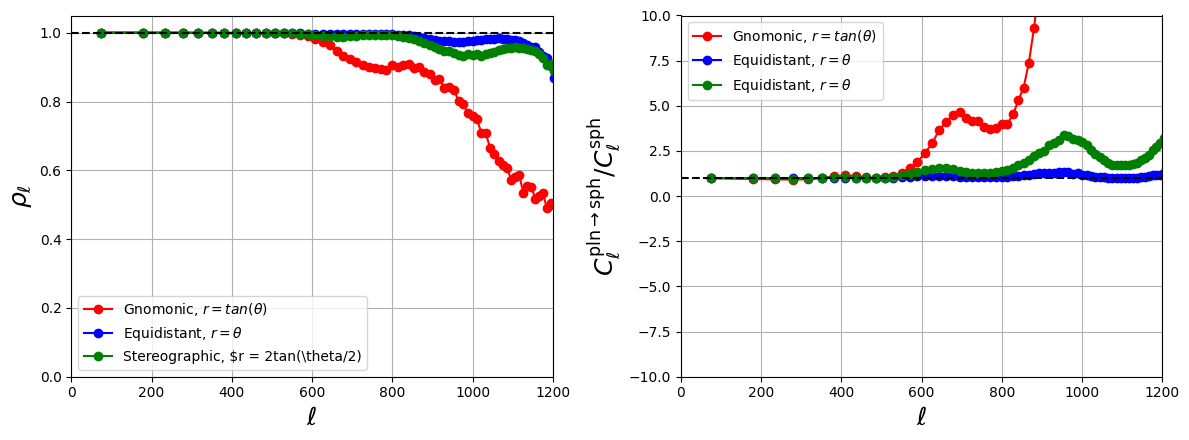

In [113]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

# Cross correlation
ax[0].plot(ells_gnom, rho_gnom[0], "o-", color='red', label=r"Gnomonic, $r = tan(\theta)$")
ax[0].plot(ells_eq, rho_eq[0], "o-", color='blue', label=r"Equidistant, $r=\theta$")
ax[0].plot(ells_str, rho_str[0], "o-", color='green', label=r"Stereographic, $r = 2tan(\theta/2)")

ax[0].axhline(1, ls="--", color="k")

ax[0].set_xlabel(r"$\ell$", fontsize=18)
ax[0].set_ylabel(r"$\rho_\ell$", fontsize=18)
ax[0].set_ylim(0, 1.05)
ax[0].set_xlim(0, 1200)
ax[0].legend()
ax[0].grid()


# Power ratio
ax[1].plot(
    ells_gnom,
    cl_pln_gnom[0] / cl_sph_gnom[0],
    "o-", color='red', 
    label=r"Gnomonic, $r = tan(\theta)$")


ax[1].plot(
    ells_eq,
    cl_pln_eq[0] / cl_sph_eq[0],
    "o-", color='blue', 
    label=r"Equidistant, $r=\theta$")

ax[1].plot(
    ells_str,
    cl_pln_str[0] / cl_sph_str[0],
    "o-", color='green', 
    label=r"Equidistant, $r=\theta$")


ax[1].axhline(1, ls="--", color="k")

ax[1].set_xlabel(r"$\ell$", fontsize=18)
ax[1].set_ylabel(
    r"$C_\ell^{\rm pln\rightarrow sph}/C_\ell^{\rm sph}$", fontsize=18)
ax[1].set_xlim(0,1200)
ax[1].set_ylim(-10,10)
ax[1].grid()
ax[1].legend()

plt.tight_layout()
plt.savefig('pseudo_cl.pdf', bbox_inches='tight')

plt.show()